In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

import os
os.makedirs("figures", exist_ok=True)

df = pd.read_csv("../data/processed/listings_enriched.csv", low_memory=False)
cal = pd.read_csv("../data/processed/calendar_clean.csv", low_memory=False)
reviews = pd.read_csv("../data/processed/reviews_clean.csv", low_memory=False)

print(f"Listings: {df.shape}")
print(f"Calendar: {cal.shape}")
print(f"Reviews: {reviews.shape}")

Listings: (28806, 96)
Calendar: (10514202, 10)
Reviews: (585941, 6)


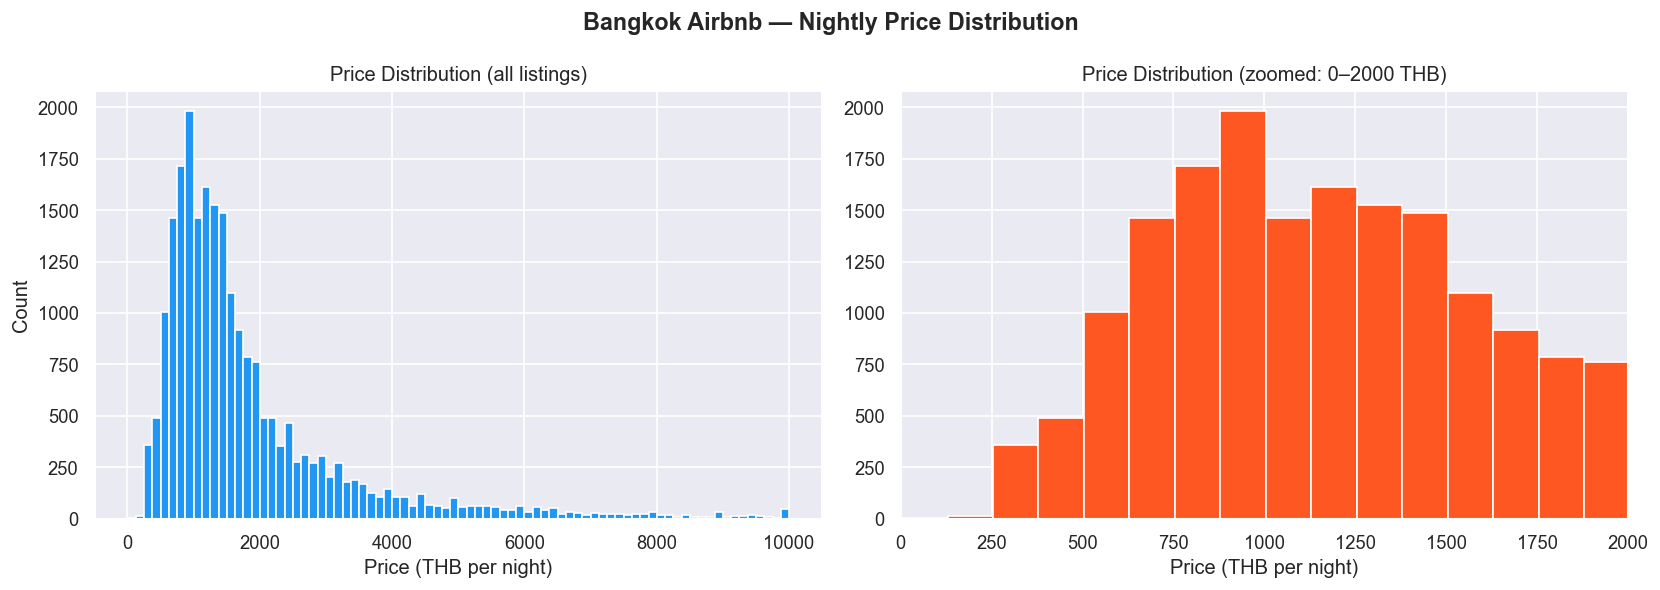

count      23273.000000
mean        2528.749151
std        16473.896035
min            4.000000
25%          923.000000
50%         1379.000000
75%         2207.000000
max      1000000.000000
Name: price, dtype: float64

Median price: 1379.0
Listings over 5000 THB: 1600


In [3]:
# --- Price Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Remove extreme outliers for visualization
price_filtered = df[df["price"].between(1, 10000)]

axes[0].hist(price_filtered["price"], bins=80, color="#2196F3", edgecolor="white")
axes[0].set_title("Price Distribution (all listings)")
axes[0].set_xlabel("Price (THB per night)")
axes[0].set_ylabel("Count")

axes[1].hist(price_filtered["price"], bins=80, color="#FF5722", edgecolor="white")
axes[1].set_xlim(0, 2000)
axes[1].set_title("Price Distribution (zoomed: 0–2000 THB)")
axes[1].set_xlabel("Price (THB per night)")

plt.suptitle("Bangkok Airbnb — Nightly Price Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/01_price_distribution.png")
plt.show()

print(df["price"].describe())
print(f"\nMedian price: {df['price'].median()}")
print(f"Listings over 5000 THB: {(df['price'] > 5000).sum()}")

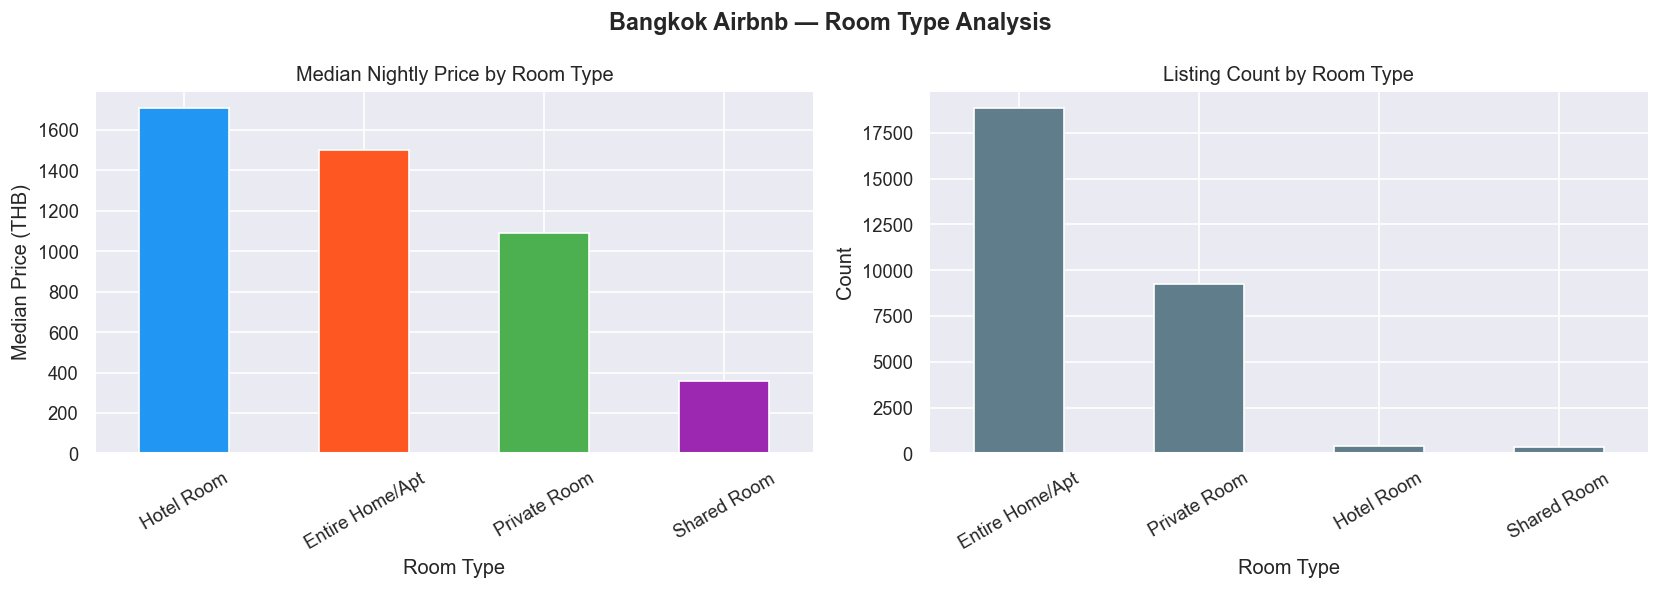

                   count         mean           std    min      25%     50%  \
room_type                                                                     
Entire Home/Apt  16498.0  2767.817069  16770.293236  274.0  1044.00  1500.0   
Hotel Room         198.0  2088.444444   1853.633733  359.0   983.25  1708.5   
Private Room      6263.0  2008.052531  16336.705682    4.0   765.00  1090.0   
Shared Room        314.0   631.171975   1087.223678   34.0   299.00   360.0   

                     75%        max  
room_type                            
Entire Home/Apt  2415.00  1000000.0  
Hotel Room       2556.25    16881.0  
Private Room     1712.00   928572.0  
Shared Room       519.00    11721.0  


In [4]:
# --- Price by Room Type ---
room_price = df.groupby("room_type")["price"].median().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Median price by room type
room_price.plot(kind="bar", ax=axes[0], color=["#2196F3","#FF5722","#4CAF50","#9C27B0"], edgecolor="white")
axes[0].set_title("Median Nightly Price by Room Type")
axes[0].set_xlabel("Room Type")
axes[0].set_ylabel("Median Price (THB)")
axes[0].tick_params(axis="x", rotation=30)

# Listing count by room type
df["room_type"].value_counts().plot(kind="bar", ax=axes[1], color="#607D8B", edgecolor="white")
axes[1].set_title("Listing Count by Room Type")
axes[1].set_xlabel("Room Type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Bangkok Airbnb — Room Type Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/02_room_type_analysis.png")
plt.show()

print(df.groupby("room_type")["price"].describe())

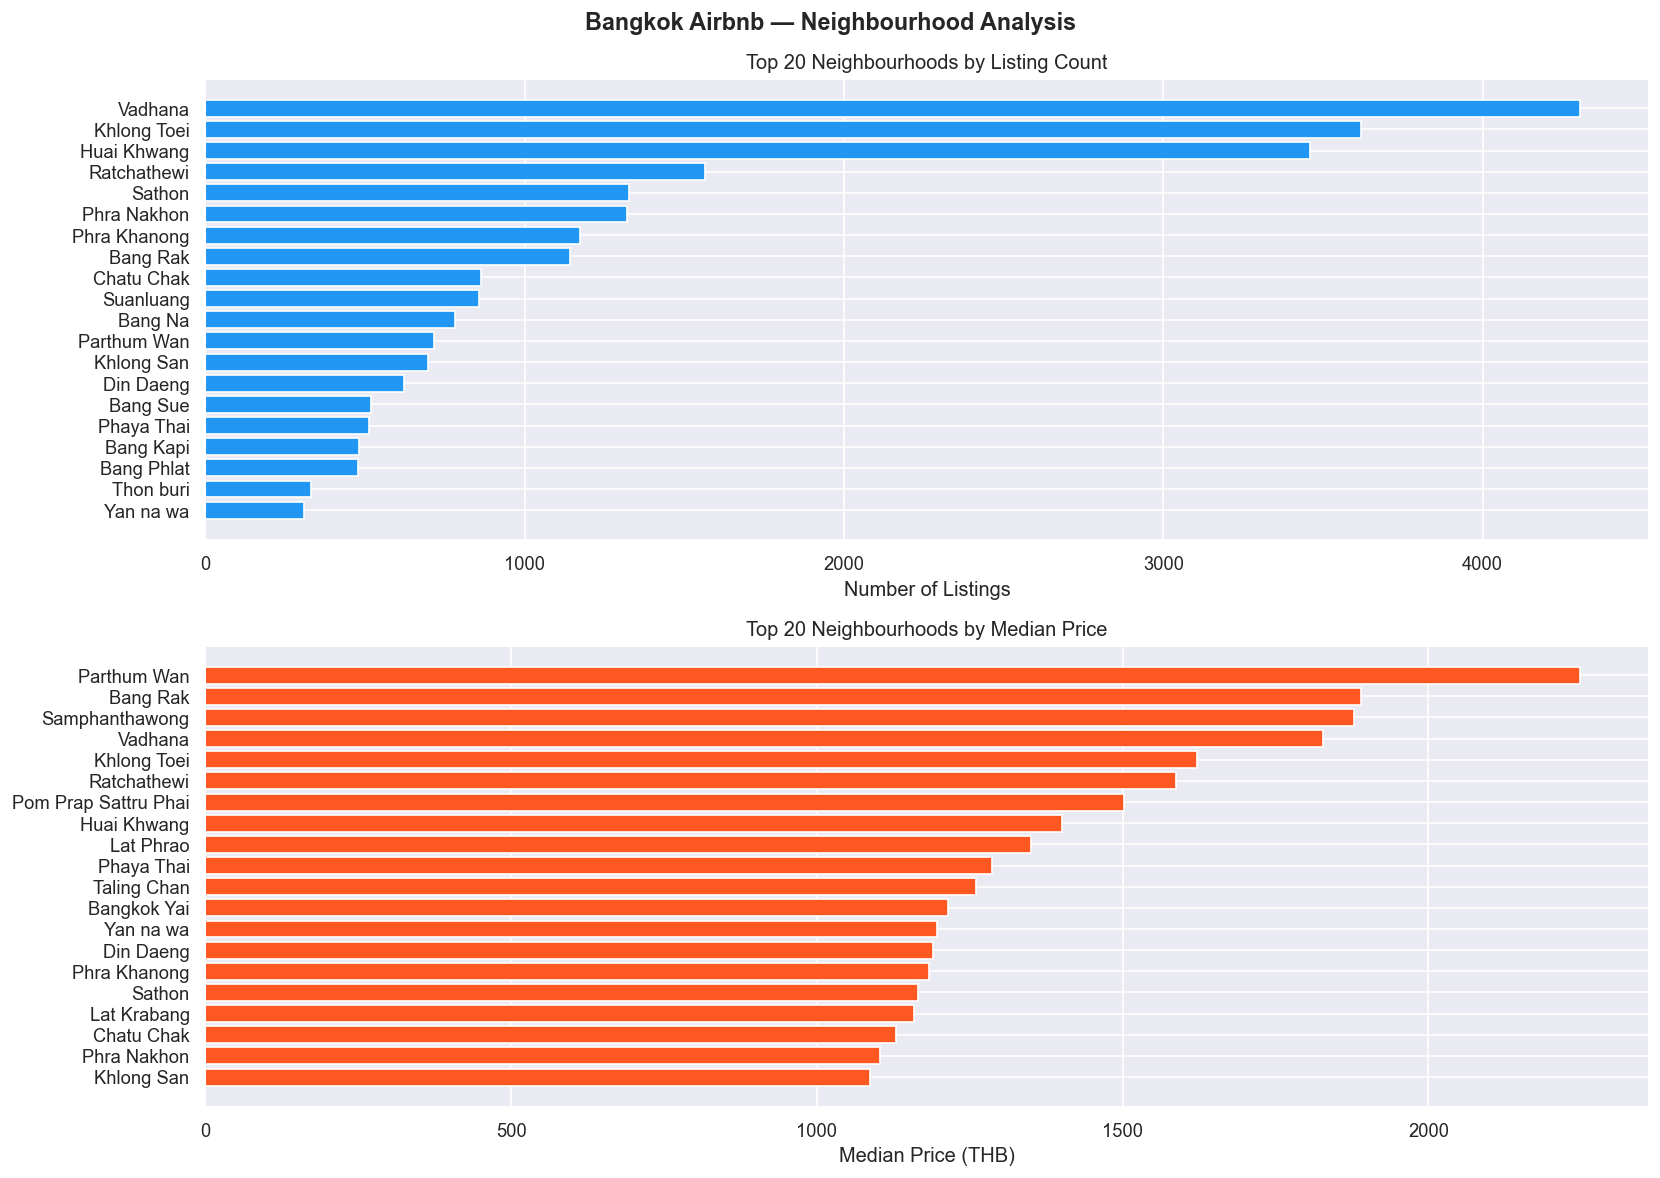

Top 10 by listing count:
   neighbourhood_cleansed  listing_count  median_price  avg_rating
47                Vadhana           4305        1828.0    4.728285
22            Khlong Toei           3620        1622.0    4.677193
18            Huai Khwang           3460        1400.0    4.603040
37            Ratchathewi           1563        1588.0    4.641332
41                 Sathon           1326        1165.0    4.670480
33            Phra Nakhon           1320        1103.0    4.630702
32           Phra Khanong           1172        1184.0    4.712515
8                Bang Rak           1141        1890.0    4.704892
13             Chatu Chak            862        1130.0    4.794845
42              Suanluang            858        1045.0    4.626164


In [6]:
# --- Top Neighbourhoods by Price and Listing Count ---
top_neighbourhoods = df.groupby("neighbourhood_cleansed").agg(
    median_price=("price", "median"),
    listing_count=("id", "count"),
    avg_rating=("review_scores_rating", "mean")
).reset_index().sort_values("listing_count", ascending=False)

top20 = top_neighbourhoods.head(20)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top 20 by listing count
axes[0].barh(top20["neighbourhood_cleansed"], top20["listing_count"], color="#2196F3")
axes[0].set_title("Top 20 Neighbourhoods by Listing Count")
axes[0].set_xlabel("Number of Listings")
axes[0].invert_yaxis()

# Top 20 by median price
top20_price = top_neighbourhoods.sort_values("median_price", ascending=False).head(20)
axes[1].barh(top20_price["neighbourhood_cleansed"], top20_price["median_price"], color="#FF5722")
axes[1].set_title("Top 20 Neighbourhoods by Median Price")
axes[1].set_xlabel("Median Price (THB)")
axes[1].invert_yaxis()

plt.suptitle("Bangkok Airbnb — Neighbourhood Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/03_neighbourhood_analysis.png")
plt.show()

print("Top 10 by listing count:")
print(top20[["neighbourhood_cleansed","listing_count","median_price","avg_rating"]].head(10).to_string())

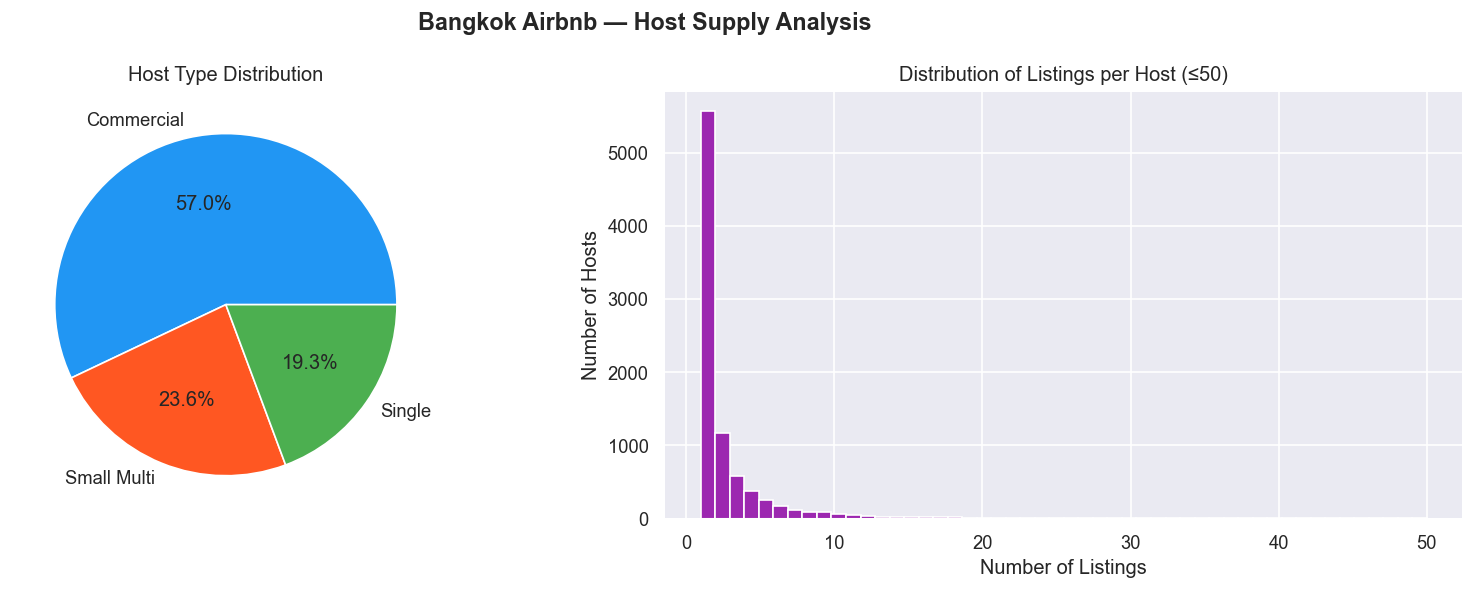

Total hosts: 8874
Single listing hosts: 5565
Commercial hosts (6+ listings): 944
Commercial listings % of market: 57.0%

Top 10 hosts by listing count:
host_id
574804920    243
493412920    193
434168399    182
201677068    174
227771817    141
680424509    135
501920630    117
52161947     110
26736483     109
260093182    109
Name: id, dtype: int64


In [7]:
# --- Host Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Host type distribution
host_type_counts = df["host_type"].value_counts()
axes[0].pie(host_type_counts.values, labels=host_type_counts.index,
            autopct="%1.1f%%", colors=["#2196F3","#FF5722","#4CAF50"])
axes[0].set_title("Host Type Distribution")

# Listings per host (top hosts)
host_listings = df.groupby("host_id")["id"].count().sort_values(ascending=False)
axes[1].hist(host_listings[host_listings <= 50], bins=50, color="#9C27B0", edgecolor="white")
axes[1].set_title("Distribution of Listings per Host (≤50)")
axes[1].set_xlabel("Number of Listings")
axes[1].set_ylabel("Number of Hosts")

plt.suptitle("Bangkok Airbnb — Host Supply Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/04_host_analysis.png")
plt.show()

# Market concentration
total_listings = len(df)
commercial_listings = df[df["host_type"] == "Commercial"]["id"].count()
single_hosts = df[df["host_type"] == "Single"]["id"].count()

print(f"Total hosts: {df['host_id'].nunique()}")
print(f"Single listing hosts: {(host_listings == 1).sum()}")
print(f"Commercial hosts (6+ listings): {(host_listings > 5).sum()}")
print(f"Commercial listings % of market: {commercial_listings/total_listings*100:.1f}%")
print(f"\nTop 10 hosts by listing count:")
print(host_listings.head(10))

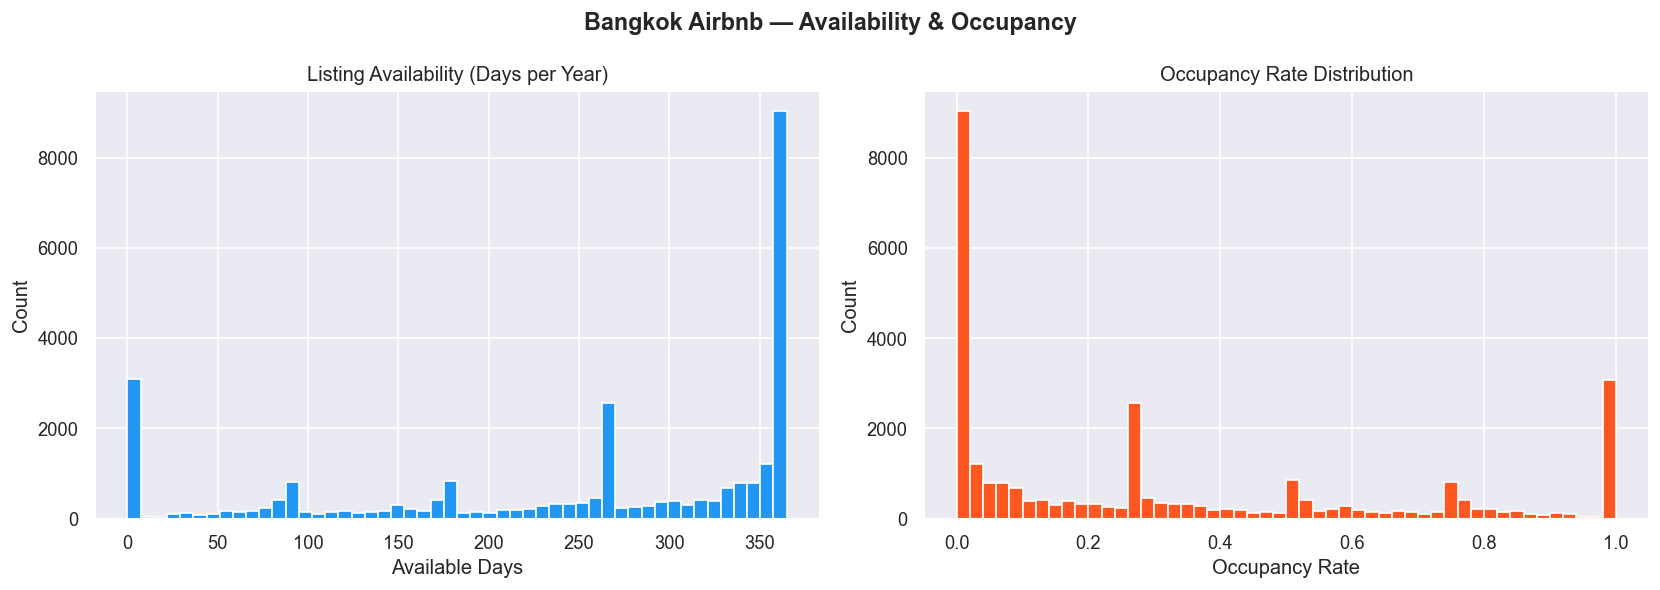

Mean occupancy rate: 31.47%
Median occupancy rate: 20.55%
Mean estimated annual revenue: nan THB
Median estimated annual revenue: nan THB
Listings with revenue data: 0

Occupancy by room type:
room_type
Hotel Room         0.374722
Private Room       0.326964
Entire Home/Apt    0.311084
Shared Room        0.116247
Name: occupancy_rate, dtype: float64


In [12]:
# --- Availability & Occupancy ---

# Recompute avg_calendar_price from calendar
cal_price = cal.groupby("listing_id")["price"].mean().reset_index()
cal_price.columns = ["id", "avg_calendar_price"]
df = df.drop(columns=["avg_calendar_price"], errors="ignore")
df = df.merge(cal_price, on="id", how="left")
df["estimated_annual_revenue"] = df["occupancy_rate"] * df["avg_calendar_price"] * 365

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avail_filtered = df[df["availability_365"] >= 0]
axes[0].hist(avail_filtered["availability_365"], bins=50, color="#2196F3", edgecolor="white")
axes[0].set_title("Listing Availability (Days per Year)")
axes[0].set_xlabel("Available Days")
axes[0].set_ylabel("Count")

occ_filtered = df[df["occupancy_rate"].between(0, 1)]
axes[1].hist(occ_filtered["occupancy_rate"], bins=50, color="#FF5722", edgecolor="white")
axes[1].set_title("Occupancy Rate Distribution")
axes[1].set_xlabel("Occupancy Rate")
axes[1].set_ylabel("Count")

plt.suptitle("Bangkok Airbnb — Availability & Occupancy", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/05_availability_occupancy.png")
plt.show()

print(f"Mean occupancy rate: {df['occupancy_rate'].mean():.2%}")
print(f"Median occupancy rate: {df['occupancy_rate'].median():.2%}")
print(f"Mean estimated annual revenue: {df['estimated_annual_revenue'].mean():,.0f} THB")
print(f"Median estimated annual revenue: {df['estimated_annual_revenue'].median():,.0f} THB")
print(f"Listings with revenue data: {df['estimated_annual_revenue'].notna().sum()}")

print("\nOccupancy by room type:")
print(df.groupby("room_type")["occupancy_rate"].mean().sort_values(ascending=False))

In [16]:
raw_cal = pd.read_csv("../data/raw/Bangkok/data/calendar.csv", nrows=5)
print(raw_cal[["price", "adjusted_price"]].head())
print(raw_cal.dtypes)

   price  adjusted_price
0    NaN             NaN
1    NaN             NaN
2    NaN             NaN
3    NaN             NaN
4    NaN             NaN
listing_id          int64
date               object
available          object
price             float64
adjusted_price    float64
minimum_nights      int64
maximum_nights      int64
dtype: object


In [17]:
# Use listing price + availability as revenue proxy
df["occupancy_rate"] = 1 - (df["availability_365"] / 365)
df["estimated_annual_revenue"] = df["price"] * (365 - df["availability_365"])

print(f"Mean occupancy rate: {df['occupancy_rate'].mean():.2%}")
print(f"Median occupancy rate: {df['occupancy_rate'].median():.2%}")
print(f"Mean estimated annual revenue: {df['estimated_annual_revenue'].mean():,.0f} THB")
print(f"Median estimated annual revenue: {df['estimated_annual_revenue'].median():,.0f} THB")
print(f"Listings with revenue data: {df['estimated_annual_revenue'].notna().sum()}")

print("\nOccupancy proxy by room type:")
print(df.groupby("room_type")["occupancy_rate"].mean().sort_values(ascending=False))

Mean occupancy rate: 31.49%
Median occupancy rate: 20.55%
Mean estimated annual revenue: 203,274 THB
Median estimated annual revenue: 61,848 THB
Listings with revenue data: 23273

Occupancy proxy by room type:
room_type
Hotel Room         0.378840
Private Room       0.326995
Entire Home/Apt    0.311411
Shared Room        0.116250
Name: occupancy_rate, dtype: float64


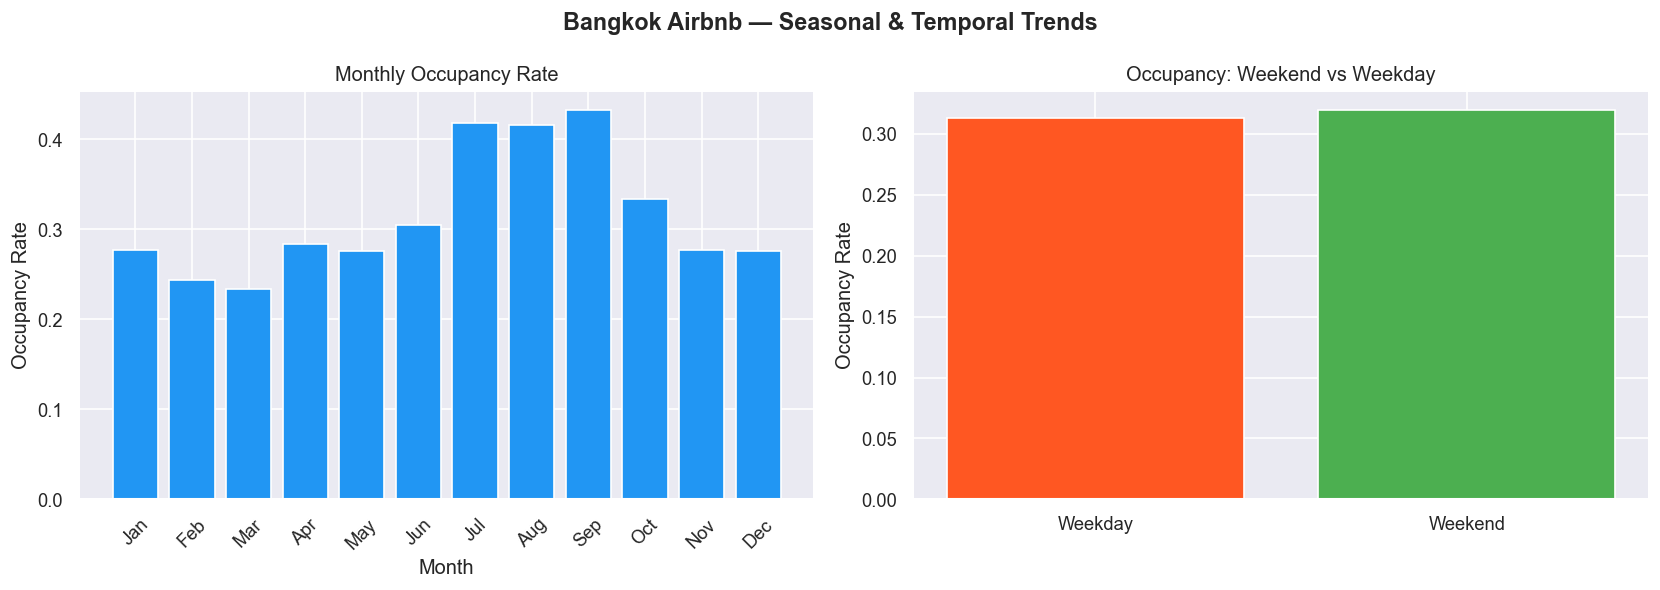

Monthly occupancy:
   month_name  occupancy_rate
0         Jan        0.276692
1         Feb        0.244081
2         Mar        0.233513
3         Apr        0.283400
4         May        0.275513
5         Jun        0.304655
6         Jul        0.417635
7         Aug        0.415671
8         Sep        0.432196
9         Oct        0.333863
10        Nov        0.277357
11        Dec        0.275778

Weekend occupancy: 31.94%
Weekday occupancy: 31.28%


In [18]:
# --- Seasonal Trends from Calendar ---
cal["date"] = pd.to_datetime(cal["date"])
cal["month"] = cal["date"].dt.month
cal["month_name"] = cal["date"].dt.strftime("%b")
cal["day_of_week"] = cal["date"].dt.day_name()
cal["is_weekend"] = cal["day_of_week"].isin(["Saturday", "Sunday"])

# Monthly availability rate
monthly_avail = cal.groupby("month")["available"].apply(
    lambda x: (x == True).sum() / len(x)
).reset_index()
monthly_avail.columns = ["month", "availability_rate"]
monthly_avail["occupancy_rate"] = 1 - monthly_avail["availability_rate"]

month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
monthly_avail["month_name"] = monthly_avail["month"].map(month_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly_avail["month_name"], monthly_avail["occupancy_rate"],
            color="#2196F3", edgecolor="white")
axes[0].set_title("Monthly Occupancy Rate")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Occupancy Rate")
axes[0].tick_params(axis="x", rotation=45)

# Weekend vs weekday occupancy
weekend_occ = cal.groupby("is_weekend")["available"].apply(
    lambda x: (x == False).sum() / len(x)
).reset_index()
weekend_occ["label"] = weekend_occ["is_weekend"].map({True: "Weekend", False: "Weekday"})
axes[1].bar(weekend_occ["label"], weekend_occ["available"],
            color=["#FF5722","#4CAF50"], edgecolor="white")
axes[1].set_title("Occupancy: Weekend vs Weekday")
axes[1].set_ylabel("Occupancy Rate")

plt.suptitle("Bangkok Airbnb — Seasonal & Temporal Trends", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/06_seasonal_trends.png")
plt.show()

print("Monthly occupancy:")
print(monthly_avail[["month_name","occupancy_rate"]].to_string())
print(f"\nWeekend occupancy: {weekend_occ[weekend_occ['is_weekend']==True]['available'].values[0]:.2%}")
print(f"Weekday occupancy: {weekend_occ[weekend_occ['is_weekend']==False]['available'].values[0]:.2%}")

In [ ]:
# --- Review Trends ---
import pandas as pd

reviews["date"] = pd.to_datetime(reviews["date"])
reviews["year"] = reviews["date"].dt.year
reviews["month"] = reviews["date"].dt.month
reviews["year_month"] = reviews["date"].dt.to_period("M")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Review volume by year
yearly = reviews[reviews["year"].between(2015, 2025)].groupby("year").size()
axes[0].bar(yearly.index, yearly.values, color="#2196F3", edgecolor="white")
axes[0].set_title("Review Volume by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Reviews")

# Review volume by month (seasonality)
monthly_reviews = reviews[reviews["year"].between(2022, 2025)].groupby(
    ["year", "month"]
).size().reset_index(name="count")
for year in [2022, 2023, 2024]:
    subset = monthly_reviews[monthly_reviews["year"] == year]
    axes[1].plot(subset["month"], subset["count"], marker="o", label=str(year))
axes[1].set_title("Monthly Review Volume (2022–2024)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Reviews")
axes[1].legend()
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=45)

plt.suptitle("Bangkok Airbnb — Review & Demand Trends", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/07_review_trends.png")
plt.show()

print("Reviews by year:")
print(yearly)

NameError: name 'pd' is not defined